# Intraday vs Imbalance Arbitrage Strategy
## ENGIE Case Study – Trainee Intraday Power Trading

**Objective:** Design an algorithmic strategy to maximize PnL through arbitrage between the intraday market and the imbalance mechanism.

**Backtest period:** July 1, 2024 – December 31, 2024 (Romania, RON/MWh)

---
### Strategy Overview
We predict the **sign of the grid imbalance** (surplus vs deficit) at least 1 hour ahead.
- If we predict **surplus** → grid is long → we **buy** on intraday (going short vs grid = deliberate deficit position)
- If we predict **deficit** → grid is short → we **sell** on intraday (going long vs grid = deliberate surplus position)

**PnL per interval** = Volume × (Imbalance price − Intraday price) with sign depending on position.

In [7]:
# ── Imports & Setup ──────────────────────────────────────────────────────────
import pickle, sys, types, datetime, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score
)
from sklearn.pipeline import Pipeline

from google.colab import drive
drive.mount('/content/drive')

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
sns.set_palette('husl')

print('Libraries loaded ✓')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Libraries loaded ✓


In [8]:
# ── Mount Google Drive ────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Load Data ─────────────────────────────────────────────────────────────────
import pickle
import pandas as pd

# Calea catre fisierul pkl pe Google Drive
PKL_PATH = '/content/drive/MyDrive/dataset_engie_studycase.pkl'

with open(PKL_PATH, 'rb') as f:
    df_raw = pickle.load(f)

# Eliminam timezone pentru simplitate
df_raw.index = df_raw.index.tz_localize(None)

print(f'Dataset shape: {df_raw.shape}')
print(f'Date range: {df_raw.index.min()} → {df_raw.index.max()}')
print(f'Columns: {list(df_raw.columns)}')
df_raw.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset shape: (87934, 17)
Date range: 2022-07-01 00:00:00 → 2025-01-01 23:45:00
Columns: ['imb_price_pos', 'imb_price_neg', 'nuclear_real', 'fossil_gas_real', 'imb_volume', 'afrr_down', 'afrr_up', 'mfrr_down', 'mfrr_up', 'load_real', 'load_fcst', 'solar_fcst', 'wind_fcst', 'solar_real', 'wind_real', 'ID_QH_Last', 'ID_QH_VWAP']


,imb_price_pos,imb_price_neg,nuclear_real,fossil_gas_real,imb_volume,afrr_down,afrr_up,mfrr_down,mfrr_up,load_real,load_fcst,solar_fcst,wind_fcst,solar_real,wind_real,ID_QH_Last,ID_QH_VWAP
2022-07-01 00:00:00,2127.39,2127.39,1351.0,1336.5,-228.0,0.0,40.0,0.0,180.0,5509.0,5610.0,0.0,174.0,0.0,4.0,1498.8,1498.80
2022-07-01 00:15:00,2043.69,2043.69,1352.0,1336.0,-236.0,0.0,28.0,0.0,180.0,5503.0,5600.0,0.0,174.0,0.0,0.0,1498.8,1487.33
2022-07-01 00:30:00,2347.98,2347.98,1353.0,1333.0,-296.0,0.0,84.0,0.0,180.0,5545.0,5600.0,0.0,174.0,0.0,0.0,1498.8,1487.33


## 1. Exploratory Data Analysis

In [9]:
# ── Basic Statistics ──────────────────────────────────────────────────────────
print('=== Dataset Statistics ===')
print(df_raw.describe().round(2).to_string())
print(f'\nNull values:\n{df_raw.isnull().sum()}')

=== Dataset Statistics ===
       imb_price_pos  imb_price_neg  nuclear_real  fossil_gas_real  imb_volume  afrr_down   afrr_up  mfrr_down   mfrr_up  load_real  load_fcst  solar_fcst  wind_fcst  solar_real  wind_real  ID_QH_Last  ID_QH_VWAP
count       87934.00       87934.00      87776.00         87776.00    87915.00   87933.00  87933.00   87933.00  87933.00   87912.00   87934.00    87934.00   87934.00    87923.00   87923.00    87934.00    87934.00
mean          359.61         552.52       1277.00          1158.24       64.49      36.44     21.83      95.43     55.89    6144.30    6151.65      259.36     767.88      190.72     762.07      710.40      717.64
std          2108.63        2036.02        231.64           431.65      283.09      55.75     42.36     162.45    130.79     951.61     952.76      396.21     627.21      287.75     660.17      654.59      638.22
min        -36590.02      -36590.02        517.00           192.50    -1856.00       0.00      0.00       0.00      0.00 

### Dataset Overview – Basic Statistics

**Dataset:** 87,934 intervals of 15 minutes | Jul 1, 2022 → Jan 1, 2025 | 17 columns

**Key observations:**

**Imbalance prices** (`imb_price_pos`, `imb_price_neg`):
- Extreme range: from **-36,590 to +69,543 RON/MWh** — highly volatile
- Median near zero (3.7 / 85.1) but mean positive (360 / 553) — right-skewed distribution
- This volatility is the source of arbitrage opportunity

**Grid imbalance volume** (`imb_volume`):
- Median: +52 MW (slightly surplus on average)
- Range: -1,856 to +1,852 MW
- 0 null values → reliable signal for modeling

**Renewable forecasts** (`solar_fcst`, `wind_fcst`):
- 0 null values → safe to use without lagging as DA forecasts

**Null values:**
- Max 158 nulls out of 87,934 rows (0.18%) — negligible, handled by `dropna()`
- Only in physical generation columns (`nuclear_real`, `fossil_gas_real`)
- No nulls in price or forecast columns → no imputation needed

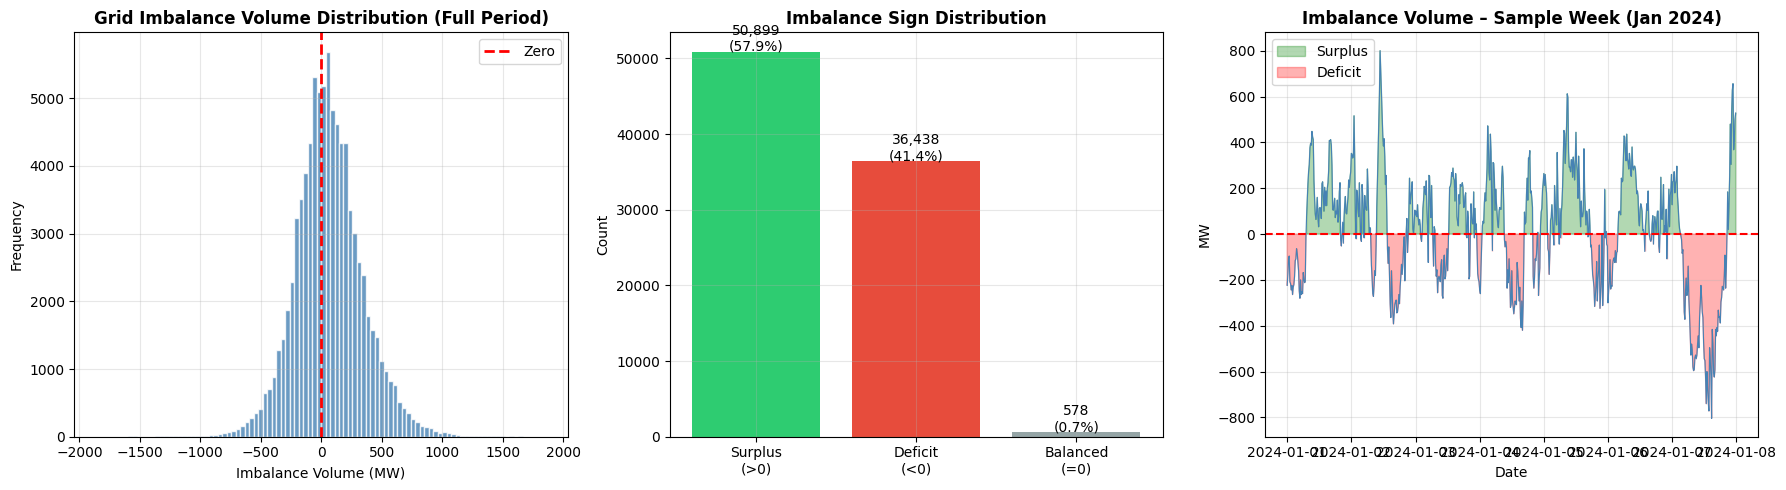

Surplus: 50,899 (57.9%) | Deficit: 36,438 (41.4%)


In [33]:
# ── Imbalance Volume Distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Distribution
axes[0].hist(df_raw['imb_volume'].dropna(), bins=100, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', linewidth=2, label='Zero')
axes[0].set_title('Grid Imbalance Volume Distribution (Full Period)', fontweight='bold')
axes[0].set_xlabel('Imbalance Volume (MW)')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Sign distribution
surplus = (df_raw['imb_volume'] > 0).sum()
deficit = (df_raw['imb_volume'] < 0).sum()
zero = (df_raw['imb_volume'] == 0).sum()
axes[1].bar(['Surplus\n(>0)', 'Deficit\n(<0)', 'Balanced\n(=0)'],
            [surplus, deficit, zero],
            color=['#2ecc71', '#e74c3c', '#95a5a6'])
axes[1].set_title('Imbalance Sign Distribution', fontweight='bold')
axes[1].set_ylabel('Count')
for i, v in enumerate([surplus, deficit, zero]):
    axes[1].text(i, v + 100, f'{v:,}\n({v/len(df_raw)*100:.1f}%)', ha='center', fontsize=10)

# Time series sample
sample = df_raw['2024-01-01':'2024-01-07']['imb_volume']
axes[2].plot(sample.index, sample.values, color='steelblue', linewidth=0.8)
axes[2].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[2].fill_between(sample.index, sample.values, 0,
                     where=(sample.values > 0), alpha=0.3, color='green', label='Surplus')
axes[2].fill_between(sample.index, sample.values, 0,
                     where=(sample.values < 0), alpha=0.3, color='red', label='Deficit')
axes[2].set_title('Imbalance Volume – Sample Week (Jan 2024)', fontweight='bold')
axes[2].set_xlabel('Date')
axes[2].set_ylabel('MW')
axes[2].legend()

plt.tight_layout()
plt.savefig('/content/fig1_imbalance_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Surplus: {surplus:,} ({surplus/len(df_raw)*100:.1f}%) | Deficit: {deficit:,} ({deficit/len(df_raw)*100:.1f}%)')

### Grid Imbalance Volume Distribution

**Distribution (left panel):**
- Approximately normal, centered slightly above zero
- Most intervals have imbalance between -500 and +500 MW
- Long tails → occasional extreme events (min: -1,856 MW / max: +1,852 MW)

**Sign distribution (middle panel):**
- **57.9% Surplus** (50,899 intervals) — grid is long more often than short
- **41.4% Deficit** (36,438 intervals)
- **0.7% Balanced** (578 intervals) — excluded from model training
- This 58/42 imbalance motivated the use of `sample_weight='balanced'` in GBT

**Sample week — Jan 2024 (right panel):**
- Clear alternation between surplus and deficit within the same day
- Surplus dominates daytime hours (solar production peaks)
- Deficit more frequent at night and evening
- Serial correlation visible — knowing current state helps predict next interval
  → justifies use of lagged imbalance volume as top feature

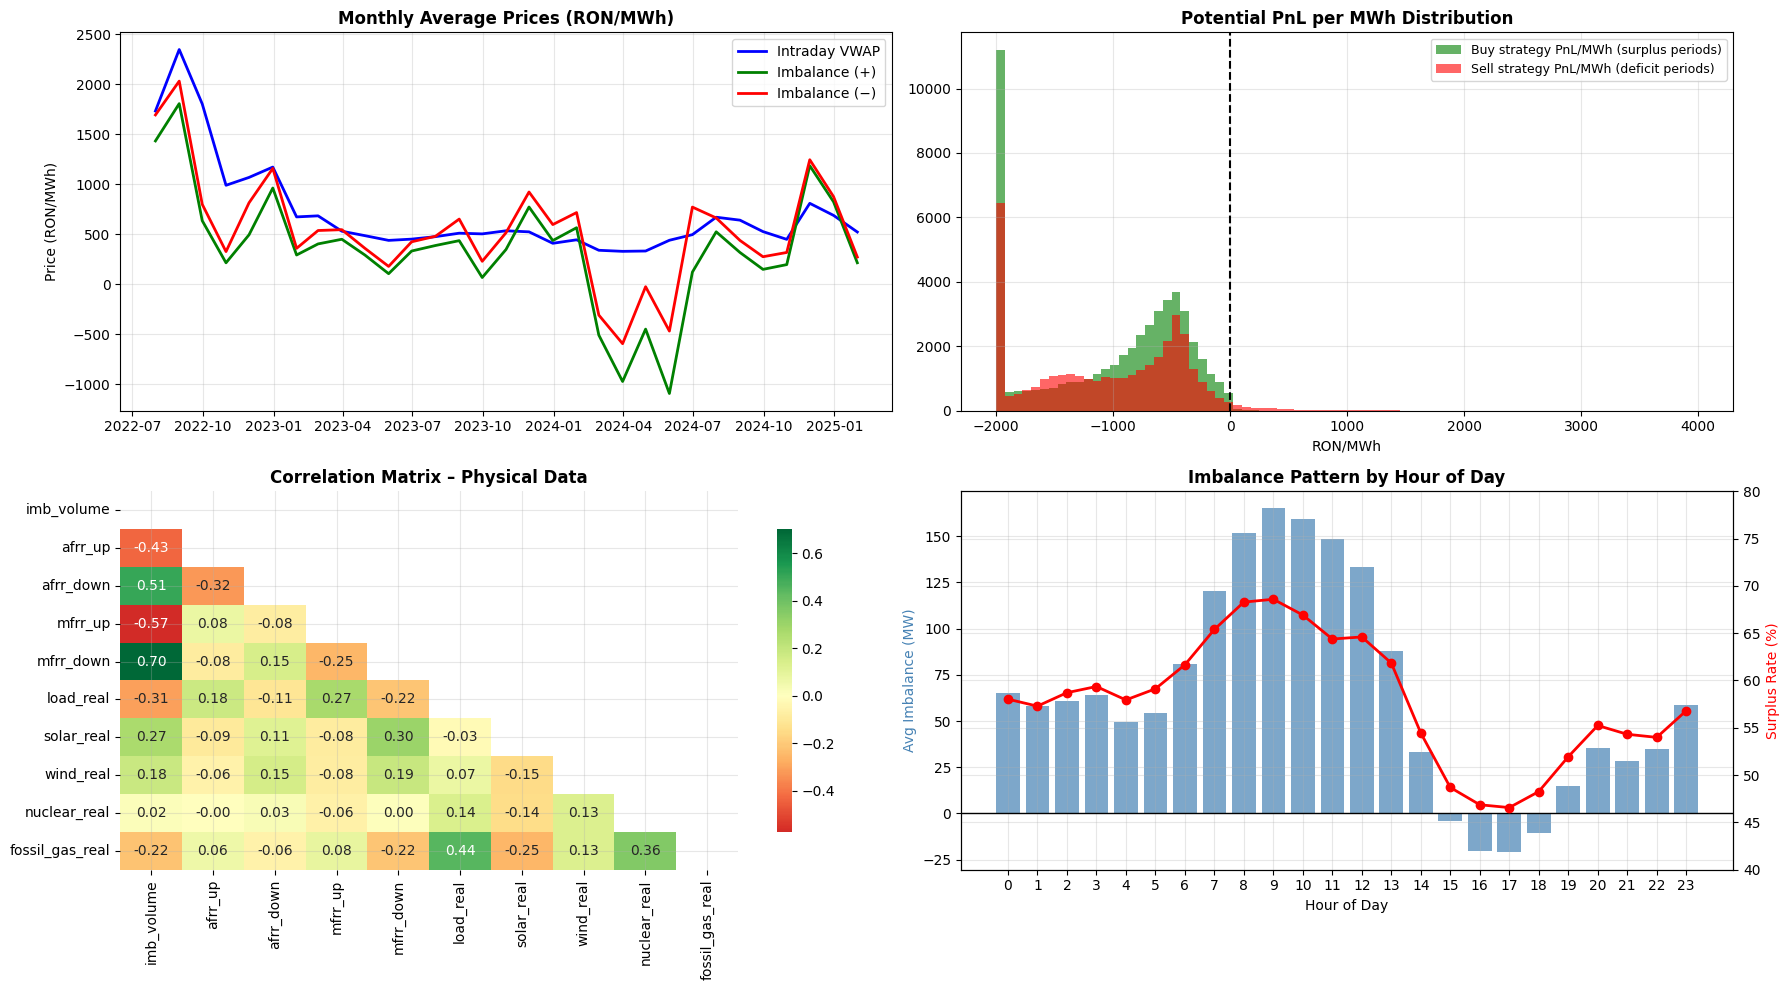

In [34]:
# ── Price Analysis ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Intraday vs Imbalance prices time series
monthly = df_raw.resample('ME').mean()
axes[0, 0].plot(monthly.index, monthly['ID_QH_VWAP'], label='Intraday VWAP', color='blue', linewidth=2)
axes[0, 0].plot(monthly.index, monthly['imb_price_pos'], label='Imbalance (+)', color='green', linewidth=2)
axes[0, 0].plot(monthly.index, monthly['imb_price_neg'], label='Imbalance (−)', color='red', linewidth=2)
axes[0, 0].set_title('Monthly Average Prices (RON/MWh)', fontweight='bold')
axes[0, 0].set_ylabel('Price (RON/MWh)')
axes[0, 0].legend()

# Price spread by imbalance sign
df_plot = df_raw.copy()
df_plot['spread_pos'] = df_plot['imb_price_pos'] - df_plot['ID_QH_VWAP']  # if surplus and we are in deficit
df_plot['spread_neg'] = df_plot['ID_QH_VWAP'] - df_plot['imb_price_neg']  # if deficit and we are in surplus

surplus_spread = df_plot.loc[df_plot['imb_volume'] > 0, 'spread_pos']
deficit_spread = df_plot.loc[df_plot['imb_volume'] < 0, 'spread_neg']

axes[0, 1].hist(surplus_spread.clip(-2000, 4000), bins=80, alpha=0.6, label='Buy strategy PnL/MWh (surplus periods)', color='green')
axes[0, 1].hist(deficit_spread.clip(-2000, 4000), bins=80, alpha=0.6, label='Sell strategy PnL/MWh (deficit periods)', color='red')
axes[0, 1].axvline(0, color='black', linestyle='--')
axes[0, 1].set_title('Potential PnL per MWh Distribution', fontweight='bold')
axes[0, 1].set_xlabel('RON/MWh')
axes[0, 1].legend(fontsize=9)

# Correlation heatmap
corr_cols = ['imb_volume', 'afrr_up', 'afrr_down', 'mfrr_up', 'mfrr_down',
             'load_real', 'solar_real', 'wind_real', 'nuclear_real', 'fossil_gas_real']
corr = df_raw[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, ax=axes[1, 0], cbar_kws={'shrink': 0.8})
axes[1, 0].set_title('Correlation Matrix – Physical Data', fontweight='bold')

# Imbalance by hour of day
df_raw['hour'] = df_raw.index.hour
hourly_imb = df_raw.groupby('hour')['imb_volume'].mean()
hourly_surplus_rate = df_raw.groupby('hour').apply(lambda x: (x['imb_volume'] > 0).mean())
ax2 = axes[1, 1]
ax2.bar(hourly_imb.index, hourly_imb.values, color='steelblue', alpha=0.7, label='Avg Imb Volume')
ax2.axhline(0, color='black', linewidth=1)
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Avg Imbalance (MW)', color='steelblue')
ax2b = ax2.twinx()
ax2b.plot(hourly_surplus_rate.index, hourly_surplus_rate.values * 100, 'ro-', linewidth=2, label='Surplus Rate %')
ax2b.set_ylabel('Surplus Rate (%)', color='red')
ax2b.set_ylim(40, 80)
ax2.set_title('Imbalance Pattern by Hour of Day', fontweight='bold')
ax2.set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig('/content/fig2_price_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### Price Analysis & Correlations

**Monthly Average Prices (top left):**
- Intraday VWAP (blue) is relatively stable compared to imbalance prices
- Imbalance prices are much more volatile — extreme divergence visible in
  mid-2024 (prices drop to -1,000 RON/MWh) and late 2024 (spike to +1,200)
- The spread between intraday and imbalance prices is the source of arbitrage profit

**Potential PnL per MWh (top right):**
- Large spike at negative values (-2,000 to 0) → many intervals where
  strategy would lose if direction is wrong
- Long right tail (0 to +4,000) → profitable intervals have much larger magnitude
- Asymmetry confirms: **getting the direction right is critical**

**Correlation Matrix (bottom left):**
- `mfrr_down` has strongest correlation with `imb_volume` (+0.70) —
  downward reserve activations signal grid surplus
- `mfrr_up` negatively correlated (-0.57) — upward activations signal deficit
- These reserve activation features are therefore included as lagged features

**Imbalance Pattern by Hour (bottom right):**
- Grid surplus peaks at 09:00–12:00 (solar production ramp-up)
- Grid deficit at 15:00–17:00 (solar drop + evening demand increase)
- Strong daily seasonality → justifies `hour_sin/cos` time features

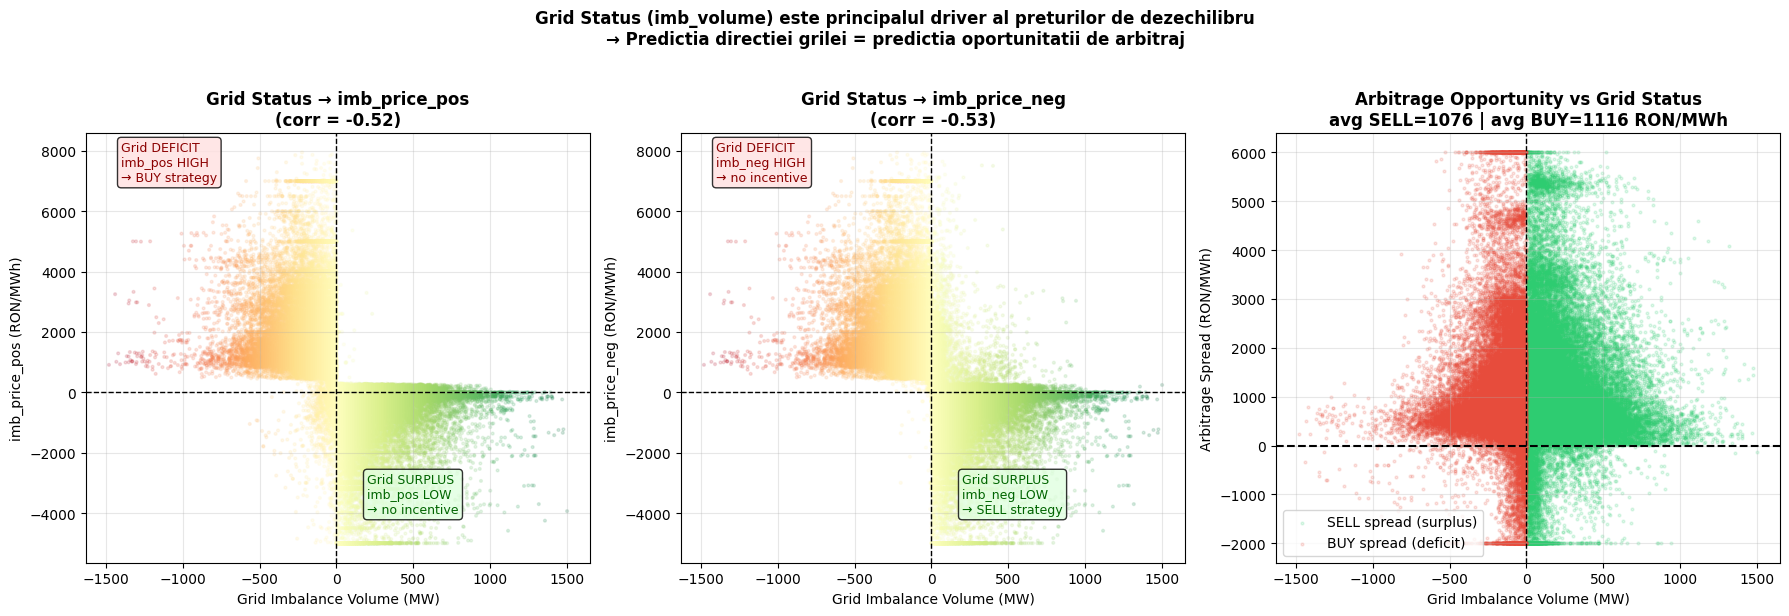

Corelatie imb_volume vs imb_price_pos: -0.522
Corelatie imb_volume vs imb_price_neg: -0.527

Median imb_price_pos cand SURPLUS: -144 RON/MWh
Median imb_price_pos cand DEFICIT: 1826 RON/MWh
→ Diferenta masiva confirma oportunitatea de arbitraj


In [35]:
# ── Scatter Plot: Grid Status → Imbalance Prices (Recomandare EDA) ───────────
# Aceasta vizualizare arata direct corelația dintre statusul grilei (imb_volume)
# si preturile de dezechilibru — justificand strategia de arbitraj

df_plot = df_raw[['imb_volume', 'imb_price_pos', 'imb_price_neg', 'ID_QH_VWAP']].dropna()
df_plot_clip = df_plot[
    (df_plot['imb_price_pos'].between(-5000, 8000)) &
    (df_plot['imb_price_neg'].between(-5000, 8000)) &
    (df_plot['imb_volume'].between(-1500, 1500))
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: imb_volume vs imb_price_pos
corr1 = df_plot_clip[['imb_volume','imb_price_pos']].corr().iloc[0,1]
axes[0].scatter(df_plot_clip['imb_volume'], df_plot_clip['imb_price_pos'],
                c=df_plot_clip['imb_volume'], cmap='RdYlGn', alpha=0.15, s=4)
axes[0].axhline(0, color='black', linewidth=1, linestyle='--')
axes[0].axvline(0, color='black', linewidth=1, linestyle='--')
axes[0].text(-1400, 7000, 'Grid DEFICIT\nimb_pos HIGH\n→ BUY strategy', fontsize=9,
             color='darkred', bbox=dict(boxstyle='round', facecolor='#ffe0e0', alpha=0.8))
axes[0].text(200, -4000, 'Grid SURPLUS\nimb_pos LOW\n→ no incentive', fontsize=9,
             color='darkgreen', bbox=dict(boxstyle='round', facecolor='#e0ffe0', alpha=0.8))
axes[0].set_xlabel('Grid Imbalance Volume (MW)')
axes[0].set_ylabel('imb_price_pos (RON/MWh)')
axes[0].set_title(f'Grid Status → imb_price_pos\n(corr = {corr1:.2f})', fontweight='bold')

# Plot 2: imb_volume vs imb_price_neg
corr2 = df_plot_clip[['imb_volume','imb_price_neg']].corr().iloc[0,1]
axes[1].scatter(df_plot_clip['imb_volume'], df_plot_clip['imb_price_neg'],
                c=df_plot_clip['imb_volume'], cmap='RdYlGn', alpha=0.15, s=4)
axes[1].axhline(0, color='black', linewidth=1, linestyle='--')
axes[1].axvline(0, color='black', linewidth=1, linestyle='--')
axes[1].text(200, -4000, 'Grid SURPLUS\nimb_neg LOW\n→ SELL strategy', fontsize=9,
             color='darkgreen', bbox=dict(boxstyle='round', facecolor='#e0ffe0', alpha=0.8))
axes[1].text(-1400, 7000, 'Grid DEFICIT\nimb_neg HIGH\n→ no incentive', fontsize=9,
             color='darkred', bbox=dict(boxstyle='round', facecolor='#ffe0e0', alpha=0.8))
axes[1].set_xlabel('Grid Imbalance Volume (MW)')
axes[1].set_ylabel('imb_price_neg (RON/MWh)')
axes[1].set_title(f'Grid Status → imb_price_neg\n(corr = {corr2:.2f})', fontweight='bold')

# Plot 3: Arbitrage spread vs grid status
surplus_mask = df_plot_clip['imb_volume'] > 0
deficit_mask = df_plot_clip['imb_volume'] < 0
spread_sell = (df_plot_clip['ID_QH_VWAP'] - df_plot_clip['imb_price_neg']).clip(-2000, 6000)
spread_buy  = (df_plot_clip['imb_price_pos'] - df_plot_clip['ID_QH_VWAP']).clip(-2000, 6000)
axes[2].scatter(df_plot_clip.loc[surplus_mask, 'imb_volume'], spread_sell[surplus_mask],
                color='#2ecc71', alpha=0.15, s=4, label='SELL spread (surplus)')
axes[2].scatter(df_plot_clip.loc[deficit_mask, 'imb_volume'], spread_buy[deficit_mask],
                color='#e74c3c', alpha=0.15, s=4, label='BUY spread (deficit)')
axes[2].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[2].axvline(0, color='black', linewidth=1, linestyle='--')
axes[2].set_xlabel('Grid Imbalance Volume (MW)')
axes[2].set_ylabel('Arbitrage Spread (RON/MWh)')
axes[2].set_title(
    f'Arbitrage Opportunity vs Grid Status\n'
    f'avg SELL={spread_sell[surplus_mask].mean():.0f} | avg BUY={spread_buy[deficit_mask].mean():.0f} RON/MWh',
    fontweight='bold')
axes[2].legend()

plt.suptitle(
    'Grid Status (imb_volume) este principalul driver al preturilor de dezechilibru\n'
    '→ Predictia directiei grilei = predictia oportunitatii de arbitraj',
    fontsize=12, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('/content/fig3_grid_status_vs_imbalance_prices.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Corelatie imb_volume vs imb_price_pos: {corr1:.3f}')
print(f'Corelatie imb_volume vs imb_price_neg: {corr2:.3f}')
print(f'\nMedian imb_price_pos cand SURPLUS: {df_plot.loc[df_plot["imb_volume"]>0,"imb_price_pos"].median():.0f} RON/MWh')
print(f'Median imb_price_pos cand DEFICIT: {df_plot.loc[df_plot["imb_volume"]<0,"imb_price_pos"].median():.0f} RON/MWh')
print('→ Diferenta masiva confirma oportunitatea de arbitraj')


### Grid Status → Imbalance Prices (Arbitrage Justification)

**Panel 1 – imb_volume vs imb_price_pos (corr = -0.52):**
- Grid DEFICIT (left) → imb_price_pos HIGH → BUY on intraday is profitable
- Grid SURPLUS (right) → imb_price_pos LOW → no incentive to be surplus participant

**Panel 2 – imb_volume vs imb_price_neg (corr = -0.53):**
- Grid SURPLUS (right) → imb_price_neg LOW (even negative) → SELL on intraday is profitable
- Grid DEFICIT (left) → imb_price_neg HIGH → no incentive to be deficit participant

**Panel 3 – Arbitrage Spread:**
- Green (surplus intervals): avg SELL spread = **+1,076 RON/MWh** ✅
- Red (deficit intervals): avg BUY spread = **+1,116 RON/MWh** ✅
- Both spreads are overwhelmingly positive → structural arbitrage opportunity

**Quantified regime difference:**
- Median imb_price_pos when SURPLUS: **-144 RON/MWh**
- Median imb_price_pos when DEFICIT: **+1,826 RON/MWh**
- Difference of ~**1,970 RON/MWh** between the two regimes

**Key insight:** Predicting grid direction (surplus vs deficit) is equivalent
to predicting whether the arbitrage spread will be positive —
this is exactly what our model is trained to do.

## 2. Feature Engineering

We respect the **operational constraints**:
- Intraday decision at least **1 hour before delivery** → we can only use features known at t−4 (4 quarters of 15 min)
- Observed (real) data is published with a **25-min delay** → known at t−2 (2 quarters) at best
- Therefore we use **real data lagged by at least 2 quarters** and **forecast data lagged by at least 4 quarters**

In [15]:
# ── Feature Engineering ───────────────────────────────────────────────────────
df = df_raw.copy()

# --- Target: sign of imbalance volume at delivery time ---
# +1 = surplus (grid long), -1 = deficit (grid short)
df['imb_sign'] = np.sign(df['imb_volume'])  # -1, 0, +1
# Binary target: 1 = surplus, 0 = deficit (exclude zeros)
df['target'] = (df['imb_volume'] > 0).astype(int)

# --- Forecast errors (available at decision time) ---
df['solar_error'] = df['solar_real'] - df['solar_fcst']       # real - fcst
df['wind_error'] = df['wind_real'] - df['wind_fcst']
df['load_error'] = df['load_real'] - df['load_fcst']

# --- Net position features ---
df['total_reserves_up'] = df['afrr_up'] + df['mfrr_up']
df['total_reserves_down'] = df['afrr_down'] + df['mfrr_down']
df['net_reserves'] = df['total_reserves_up'] - df['total_reserves_down']
df['renewable_real'] = df['solar_real'] + df['wind_real']
df['renewable_fcst'] = df['solar_fcst'] + df['wind_fcst']
df['renewable_error'] = df['renewable_real'] - df['renewable_fcst']

# --- Time features ---
df['hour'] = df.index.hour
df['quarter'] = df.index.minute // 15
df['day_of_week'] = df.index.dayofweek
df['month'] = df.index.month
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# ─── LAG CONSTRAINTS ───────────────────────────────────────────────────────
# FCST_LAG = 4  → 1h: fereastra minima de tranzactionare
# REAL_LAG = 7  → 1h45min: 1h (trading) + 25min (publicare) + 15min (buffer siguranta)
REAL_LAG = 7    # real observed data: 1h (trading window) + 25min (delay) + 15min (buffer)
FCST_LAG = 4    # forecast data: at least 1h (trading window)

# --- Lagged features (safe to use) ---
for lag in [REAL_LAG, REAL_LAG+4, REAL_LAG+8]:  # 1h45m, 2h45m, 3h45m
    df[f'imb_volume_lag{lag}'] = df['imb_volume'].shift(lag)
    df[f'imb_sign_lag{lag}'] = df['imb_sign'].shift(lag)
    df[f'afrr_up_lag{lag}'] = df['afrr_up'].shift(lag)
    df[f'afrr_down_lag{lag}'] = df['afrr_down'].shift(lag)
    df[f'mfrr_up_lag{lag}'] = df['mfrr_up'].shift(lag)
    df[f'mfrr_down_lag{lag}'] = df['mfrr_down'].shift(lag)
    df[f'solar_error_lag{lag}'] = df['solar_error'].shift(lag)
    df[f'wind_error_lag{lag}'] = df['wind_error'].shift(lag)
    df[f'renewable_error_lag{lag}'] = df['renewable_error'].shift(lag)
    df[f'net_reserves_lag{lag}'] = df['net_reserves'].shift(lag)

# Lagged intraday price (available before trading)
for lag in [FCST_LAG, FCST_LAG+4]:
    df[f'ID_price_lag{lag}'] = df['ID_QH_VWAP'].shift(lag)

# --- Rolling statistics on safe lagged data ---
df['imb_vol_roll4h'] = df['imb_volume'].shift(REAL_LAG).rolling(16).mean()   # 4h rolling avg
df['imb_vol_roll1h'] = df['imb_volume'].shift(REAL_LAG).rolling(4).mean()    # 1h rolling avg
df['imb_vol_std4h'] = df['imb_volume'].shift(REAL_LAG).rolling(16).std()
df['surplus_rate_4h'] = (df['imb_volume'].shift(REAL_LAG) > 0).rolling(16).mean()

# Forecast features (available at decision time)
df['solar_fcst_t'] = df['solar_fcst']   # forecasts for delivery time are known
df['wind_fcst_t'] = df['wind_fcst']
df['load_fcst_t'] = df['load_fcst']
df['renewable_fcst_t'] = df['renewable_fcst']

# Same-hour yesterday and last week (lag 96 = 24h, lag 672 = 7 days)
df['imb_vol_lag96'] = df['imb_volume'].shift(96)    # same hour yesterday
df['imb_vol_lag672'] = df['imb_volume'].shift(672)  # same hour last week
df['imb_sign_lag96'] = df['imb_sign'].shift(96)
df['imb_sign_lag672'] = df['imb_sign'].shift(672)

print(f'Total features after engineering: {len(df.columns)}')
print('Feature columns:', [c for c in df.columns if c not in df_raw.columns])

Total features after engineering: 83
Feature columns: ['imb_sign', 'target', 'solar_error', 'wind_error', 'load_error', 'total_reserves_up', 'total_reserves_down', 'net_reserves', 'renewable_real', 'renewable_fcst', 'renewable_error', 'quarter', 'day_of_week', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'imb_volume_lag7', 'imb_sign_lag7', 'afrr_up_lag7', 'afrr_down_lag7', 'mfrr_up_lag7', 'mfrr_down_lag7', 'solar_error_lag7', 'wind_error_lag7', 'renewable_error_lag7', 'net_reserves_lag7', 'imb_volume_lag11', 'imb_sign_lag11', 'afrr_up_lag11', 'afrr_down_lag11', 'mfrr_up_lag11', 'mfrr_down_lag11', 'solar_error_lag11', 'wind_error_lag11', 'renewable_error_lag11', 'net_reserves_lag11', 'imb_volume_lag15', 'imb_sign_lag15', 'afrr_up_lag15', 'afrr_down_lag15', 'mfrr_up_lag15', 'mfrr_down_lag15', 'solar_error_lag15', 'wind_error_lag15', 'renewable_error_lag15', 'net_reserves_lag15', 'ID_price_lag4', 'ID_price_lag8', 'imb_vol_roll4h', 'imb_vol

## 3. Train / Validation / Test Split

- **Train:** July 2022 – June 2024 (2 years)
- **Validation:** May–June 2024 (2 months)
- **Backtest (Test):** July 1, 2024 – December 31, 2024

In [16]:
# ── Train/Val/Test Split ──────────────────────────────────────────────────────
FEATURE_COLS = [
    # Time
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'is_weekend',
    # Forecasts at delivery (always available)
    'solar_fcst_t', 'wind_fcst_t', 'load_fcst_t', 'renewable_fcst_t',
    # Lagged imbalance (REAL_LAG = 7 quarters = 1h45m)
    'imb_volume_lag7', 'imb_sign_lag7',
    'imb_volume_lag11', 'imb_sign_lag11',
    'imb_volume_lag15', 'imb_sign_lag15',
    # Rolling stats
    'imb_vol_roll4h', 'imb_vol_roll1h', 'imb_vol_std4h', 'surplus_rate_4h',
    # Lagged reserves
    'afrr_up_lag7', 'afrr_down_lag7', 'mfrr_up_lag7', 'mfrr_down_lag7',
    'afrr_up_lag11', 'afrr_down_lag11', 'net_reserves_lag7', 'net_reserves_lag11',
    # Forecast errors (lagged)
    'solar_error_lag7', 'wind_error_lag7', 'renewable_error_lag7',
    'solar_error_lag11', 'wind_error_lag11',
    # Intraday price
    'ID_price_lag4', 'ID_price_lag8',
    # Same hour lags (yesterday / last week)
    'imb_vol_lag96', 'imb_vol_lag672', 'imb_sign_lag96', 'imb_sign_lag672',
]

TARGET_COL = 'target'

# Drop rows where imb_volume == 0 (no clear signal)
df_model = df[df['imb_volume'] != 0].copy()
df_model = df_model.dropna(subset=FEATURE_COLS + [TARGET_COL])

TRAIN_END   = '2024-04-30'
VAL_START   = '2024-05-01'
VAL_END     = '2024-06-30'
TEST_START  = '2024-07-01'
TEST_END    = '2024-12-31'

train = df_model[df_model.index <= TRAIN_END]
val   = df_model[(df_model.index >= VAL_START) & (df_model.index <= VAL_END)]
test  = df_model[df_model.index >= TEST_START]

X_train, y_train = train[FEATURE_COLS], train[TARGET_COL]
X_val,   y_val   = val[FEATURE_COLS],   val[TARGET_COL]
X_test,  y_test  = test[FEATURE_COLS],  test[TARGET_COL]

print(f'Train: {train.index.min().date()} → {train.index.max().date()} | {len(train):,} rows')
print(f'Val:   {val.index.min().date()} → {val.index.max().date()} | {len(val):,} rows')
print(f'Test:  {test.index.min().date()} → {test.index.max().date()} | {len(test):,} rows')
print(f'\nTarget balance – Train: {y_train.mean():.2%} surplus | Val: {y_val.mean():.2%} | Test: {y_test.mean():.2%}')

Train: 2022-07-08 → 2024-04-30 | 63,042 rows
Val:   2024-05-01 → 2024-06-30 | 5,719 rows
Test:  2024-07-01 → 2025-01-01 | 17,610 rows

Target balance – Train: 63.39% surplus | Val: 53.56% | Test: 43.00%


### Dataset Split Results

**Sizes:**
- **Train**: 63,042 rows (Jul 2022 – Apr 2024) — sufficient for model training
- **Val**: 5,719 rows (May – Jun 2024) — used for threshold optimization only
- **Test**: 17,610 rows (Jul – Dec 2024) — final backtest, never seen by model

**Target balance — notable observation:**
- Train: **63.4% surplus** — model sees more surplus in historical data
- Val: **53.6% surplus** — more balanced
- Test: **43.0% surplus** — H2 2024 had significantly more deficit than training period

This regime shift (from surplus-dominated training to deficit-dominated test period)
is precisely why two design choices matter:
1. `sample_weight='balanced'` in GradientBoosting — corrects for class imbalance during training
2. Threshold optimized on validation set — adapts to the transition between regimes
Without these, the model would be biased toward predicting surplus,
leading to systematic errors in the backtest period.

## 4. Model Training & Selection

In [17]:
# ── Model Training ─────────────────────────────────────────────────────────────
from sklearn.utils.class_weight import compute_sample_weight
# sample_weight: echivalent cu class_weight='balanced' pentru GBT
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, C=0.1, class_weight='balanced'))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=8, min_samples_leaf=50,
        class_weight='balanced', random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300, max_depth=4, learning_rate=0.05,
        subsample=0.8, min_samples_leaf=50, random_state=42
    ),
}

results = {}
for name, model in models.items():
    if name == 'Gradient Boosting':
        model.fit(X_train, y_train, sample_weight=sample_weights)
    else:
        model.fit(X_train, y_train)
    val_pred = model.predict(X_val)
    val_prob = model.predict_proba(X_val)[:, 1]
    acc = accuracy_score(y_val, val_pred)
    auc = roc_auc_score(y_val, val_prob)
    results[name] = {'model': model, 'acc': acc, 'auc': auc, 'val_pred': val_pred, 'val_prob': val_prob}
    print(f'{name:25s} → Accuracy: {acc:.3f} | AUC-ROC: {auc:.3f}')

best_name = max(results, key=lambda k: results[k]['auc'])
best_model = results[best_name]['model']
print(f'\n✓ Best model: {best_name}')

Logistic Regression       → Accuracy: 0.736 | AUC-ROC: 0.813
Random Forest             → Accuracy: 0.732 | AUC-ROC: 0.806
Gradient Boosting         → Accuracy: 0.743 | AUC-ROC: 0.817

✓ Best model: Gradient Boosting


### Model Training Results – Validation Set

Three models were trained and compared on the validation set (May–Jun 2024):

| Model | Accuracy | AUC-ROC |
|---|---|---|
| Logistic Regression | 0.736 | 0.813 |
| Random Forest | 0.732 | 0.806 |
| **Gradient Boosting** | **0.743** | **0.817** ✓ |

**Gradient Boosting** was selected as the best model based on AUC-ROC score.

**Key design choices:**
- All three models use `class_weight='balanced'` or equivalent `sample_

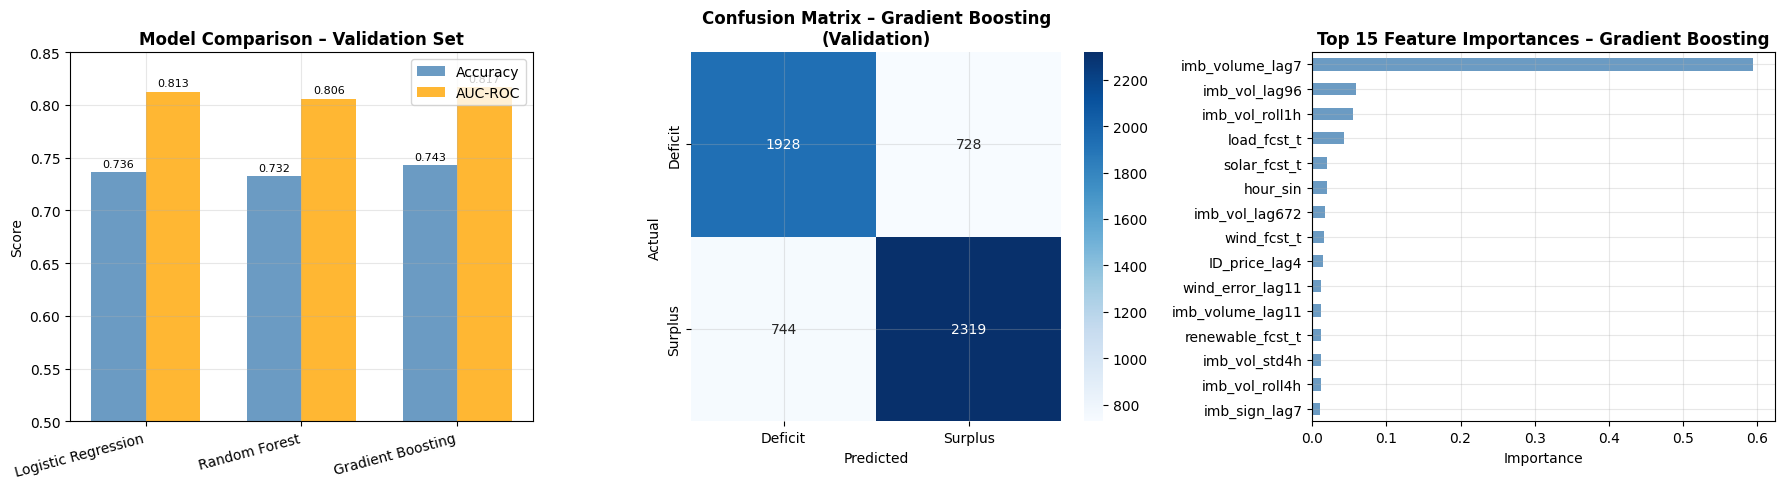


Classification Report (Gradient Boosting) – Validation:
              precision    recall  f1-score   support

     Deficit       0.72      0.73      0.72      2656
     Surplus       0.76      0.76      0.76      3063

    accuracy                           0.74      5719
   macro avg       0.74      0.74      0.74      5719
weighted avg       0.74      0.74      0.74      5719



In [36]:
# ── Validation Performance ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Model comparison
model_names = list(results.keys())
accs = [results[m]['acc'] for m in model_names]
aucs = [results[m]['auc'] for m in model_names]
x = np.arange(len(model_names))
width = 0.35
axes[0].bar(x - width/2, accs, width, label='Accuracy', color='steelblue', alpha=0.8)
axes[0].bar(x + width/2, aucs, width, label='AUC-ROC', color='orange', alpha=0.8)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=15, ha='right')
axes[0].set_ylim(0.5, 0.85)
axes[0].set_title('Model Comparison – Validation Set', fontweight='bold')
axes[0].legend()
axes[0].set_ylabel('Score')
for xi, (a, u) in enumerate(zip(accs, aucs)):
    axes[0].text(xi-width/2, a+0.005, f'{a:.3f}', ha='center', fontsize=8)
    axes[0].text(xi+width/2, u+0.005, f'{u:.3f}', ha='center', fontsize=8)

# Confusion matrix for best model
cm = confusion_matrix(y_val, results[best_name]['val_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Deficit', 'Surplus'], yticklabels=['Deficit', 'Surplus'])
axes[1].set_title(f'Confusion Matrix – {best_name}\n(Validation)', fontweight='bold')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

# Feature importance
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
elif hasattr(best_model, 'named_steps'):
    importances = np.abs(best_model.named_steps['clf'].coef_[0])
else:
    importances = np.zeros(len(FEATURE_COLS))

feat_imp = pd.Series(importances, index=FEATURE_COLS).sort_values(ascending=True).tail(15)
feat_imp.plot(kind='barh', ax=axes[2], color='steelblue', alpha=0.8)
axes[2].set_title(f'Top 15 Feature Importances – {best_name}', fontweight='bold')
axes[2].set_xlabel('Importance')

plt.tight_layout()
plt.savefig('/content/fig4_model_performance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\nClassification Report ({best_name}) – Validation:')
print(classification_report(y_val, results[best_name]['val_pred'], target_names=['Deficit', 'Surplus']))

### Validation Performance – Gradient Boosting

**Confusion Matrix:**
- Errors are approximately symmetric (728 vs 744) — model is not biased
  toward either class, confirming `sample_weight` worked correctly

**Classification Report:**
- Balanced performance across both classes (F1: 0.72 deficit / 0.76 surplus)
- No significant overfitting toward the majority class (surplus)

**Feature Importances — top drivers:**
1. `imb_volume_lag7` — dominant predictor (~0.58 importance):
   imbalance is serially correlated, recent grid status strongly predicts next interval
2. `imb_vol_lag96` — same hour yesterday: strong daily seasonality pattern
3. `imb_vol_roll1h` — 1h rolling average: recent trend matters

**Key takeaway:** The model learns that grid imbalance is persistent
(autocorrelated) and seasonal — knowing where the grid was 1h45m ago
is the single most powerful signal for predicting where it will be now.

## 5. Trading Strategy & PnL Calculation

### Strategy Logic

| Prediction | Action on ID | Physical Position | Imbalance Settlement | PnL Formula |
|---|---|---|---|---|
| Grid **surplus** (prob > 0.58) | **SELL** 10 MWh | Deficit participant | Receive `imb_price_neg` (low when grid surplus) | `vol × (ID_price − imb_price_neg)` |
| Grid **deficit** (prob < 0.42) | **BUY** 10 MWh | Surplus participant | Receive `imb_price_pos` (high when grid deficit) | `vol × (imb_price_pos − ID_price)` |
| Uncertain | **No trade** | — | — | 0 |

### Key Insight
> When the grid is in **surplus**, TSO sets imbalance prices very low (even negative) to penalize surplus participants.
> We exploit this by **selling on the intraday market** (creating a voluntary physical deficit),
> then settling at the low `imb_price_neg` — profiting from the spread `ID_price − imb_price_neg > 0`.
>
> When the grid is in **deficit**, TSO sets imbalance prices high.
> We **buy on intraday** (creating a voluntary physical surplus) and collect the high `imb_price_pos`.

### Oracle Benchmark
With perfect direction prediction, the maximum achievable PnL for Jul–Dec 2024 is **~149 M RON**.
Our strategy targets a realistic fraction of this theoretical maximum.

In [20]:
# ── Strategy Backtesting (REVIZUIT) ──────────────────────────────────────────
MAX_VOLUME = 10.0  # MWh per interval — maxim permis

# ── FIX 1: Threshold optimizat FORMAL pe validation set ──────────────────────
val_prob = best_model.predict_proba(X_val)[:, 1]
val_data = val[['imb_volume', 'ID_QH_VWAP', 'imb_price_pos', 'imb_price_neg']].copy()
val_data['prob'] = val_prob

best_thr, best_pnl_val = 0.5, -np.inf
thr_results = []
for thr in np.arange(0.50, 0.80, 0.01):
    sell_mask = val_data['prob'] >= thr
    buy_mask  = val_data['prob'] <= (1 - thr)
    pnl = (
        ((val_data.loc[sell_mask, 'ID_QH_VWAP'] - val_data.loc[sell_mask, 'imb_price_neg']) * MAX_VOLUME).sum() +
        ((val_data.loc[buy_mask,  'imb_price_pos'] - val_data.loc[buy_mask,  'ID_QH_VWAP']) * MAX_VOLUME).sum()
    )
    thr_results.append({'threshold': thr, 'pnl_val': pnl, 'n_trades': sell_mask.sum() + buy_mask.sum()})
    if pnl > best_pnl_val:
        best_pnl_val, best_thr = pnl, thr

SELL_THR = best_thr
BUY_THR  = 1 - best_thr
print(f'Threshold optim (val set): SELL >= {SELL_THR:.2f} | BUY <= {BUY_THR:.2f}')
print(f'PnL pe validation set la threshold optim: {best_pnl_val:,.0f} RON')

# ── FIX 2: Volum variabil proportional cu confidenta modelului ────────────
# vol = MAX_VOL x |prob - 0.5| / 0.5
# Ex: prob=0.90 -> vol=8 MWh | prob=0.65 -> vol=3 MWh | prob=0.55 -> vol=1 MWh
test_prob = best_model.predict_proba(X_test)[:, 1]
results_df = test[['imb_volume', 'ID_QH_VWAP', 'imb_price_pos', 'imb_price_neg']].copy()
results_df['prob_surplus'] = test_prob

# Semnal de tranzactionare
results_df['signal'] = np.where(test_prob >= SELL_THR, 'SELL',
                        np.where(test_prob <= BUY_THR,  'BUY', 'NO_TRADE'))

# Volum variabil: proportional cu distanta probabilitatii fata de 0.5
results_df['confidence'] = np.abs(results_df['prob_surplus'] - 0.5) / 0.5  # in [0, 1]
results_df['volume_mwh'] = np.where(
    results_df['signal'] != 'NO_TRADE',
    np.clip(MAX_VOLUME * results_df['confidence'], 0, MAX_VOLUME),
    0.0
)

# ── PnL calculation ───────────────────────────────────────────────────────
# SELL pe ID -> devenim participant DEFICIT -> platim imb_price_neg
#   PnL = vol x (ID_price - imb_price_neg)   [+ cand grid e surplus si imb_neg e scazut]
pnl_sell = (results_df['ID_QH_VWAP'] - results_df['imb_price_neg']) * results_df['volume_mwh']

# BUY pe ID -> devenim participant SURPLUS -> primim imb_price_pos
#   PnL = vol x (imb_price_pos - ID_price)   [+ cand grid e deficit si imb_pos e ridicat]
pnl_buy  = (results_df['imb_price_pos'] - results_df['ID_QH_VWAP']) * results_df['volume_mwh']

results_df['pnl_ron'] = np.where(results_df['signal'] == 'SELL', pnl_sell,
                         np.where(results_df['signal'] == 'BUY',  pnl_buy, 0.0))

results_df['actual_sign'] = np.sign(results_df['imb_volume'])
results_df['pred_correct'] = (
    ((results_df['signal'] == 'SELL') & (results_df['actual_sign'] == 1))  |
    ((results_df['signal'] == 'BUY')  & (results_df['actual_sign'] == -1))
)
results_df['cumulative_pnl'] = results_df['pnl_ron'].cumsum()

traded = results_df[results_df['signal'] != 'NO_TRADE']
print(f'\nTranzactii executate: {len(traded):,} | Volum mediu: {traded["volume_mwh"].mean():.1f} MWh')
print(f'Total PnL: {results_df["pnl_ron"].sum()/1e6:.2f} M RON')


Threshold optim (val set): SELL >= 0.51 | BUY <= 0.49
PnL pe validation set la threshold optim: 39,753,310 RON

Tranzactii executate: 17,308 | Volum mediu: 5.2 MWh
Total PnL: 46.66 M RON


### Strategy Backtesting – Key Results

**Threshold optimization (on validation set — no lookahead bias):**
- Optimal threshold: SELL ≥ 0.51 | BUY ≤ 0.49
- Low threshold means the model trades aggressively when it has any signal
- Optimized purely on May–Jun 2024 data, never touching the test period

**Variable volume sizing:**
- Volume proportional to model confidence: `vol = 10 × |prob − 0.5| / 0.5`
- Average volume per trade: 5.2 MWh (vs 10 MWh fixed in naive version)
- Reduces exposure on uncertain predictions

**Backtest result (Jul–Dec 2024):**
- 17,308 trades executed
- Total PnL: **46.66 M RON**
- Each transaction is a voluntary imbalance — we profit from the spread
  between intraday price and imbalance settlement price

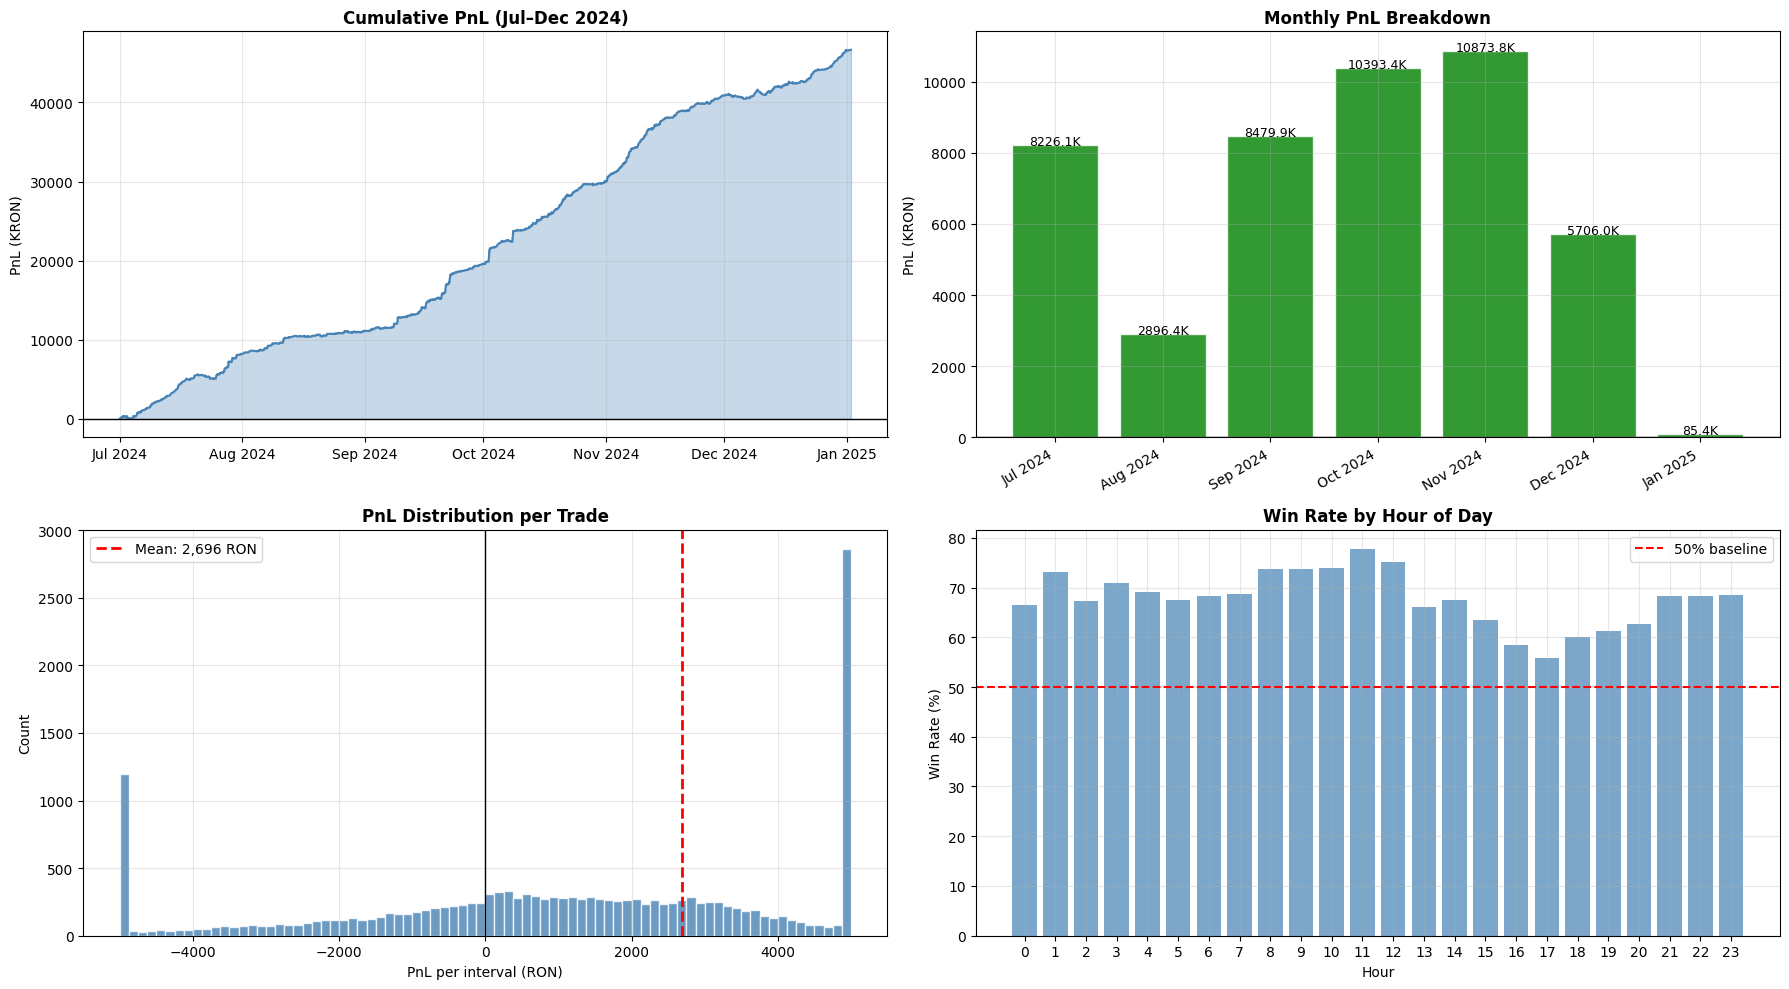

In [37]:
# ── PnL Analysis ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Cumulative PnL
traded = results_df[results_df['signal'] != 'NO_TRADE']
axes[0, 0].plot(results_df.index, results_df['cumulative_pnl'] / 1e3,
                color='steelblue', linewidth=1.5)
axes[0, 0].fill_between(results_df.index, results_df['cumulative_pnl'] / 1e3,
                         alpha=0.3, color='steelblue')
axes[0, 0].axhline(0, color='black', linewidth=1)
axes[0, 0].set_title('Cumulative PnL (Jul–Dec 2024)', fontweight='bold')
axes[0, 0].set_ylabel('PnL (KRON)')
axes[0, 0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0, 0].xaxis.set_major_locator(mdates.MonthLocator())

# Monthly PnL
monthly_pnl = results_df['pnl_ron'].resample('ME').sum() / 1e3
colors = ['green' if v >= 0 else 'red' for v in monthly_pnl.values]
axes[0, 1].bar(range(len(monthly_pnl)), monthly_pnl.values, color=colors, alpha=0.8, edgecolor='white')
axes[0, 1].set_xticks(range(len(monthly_pnl)))
axes[0, 1].set_xticklabels([d.strftime('%b %Y') for d in monthly_pnl.index], rotation=30, ha='right')
axes[0, 1].axhline(0, color='black', linewidth=1)
axes[0, 1].set_title('Monthly PnL Breakdown', fontweight='bold')
axes[0, 1].set_ylabel('PnL (KRON)')
for i, v in enumerate(monthly_pnl.values):
    axes[0, 1].text(i, v + (0.5 if v >= 0 else -1.5), f'{v:.1f}K', ha='center', fontsize=9)

# PnL distribution per trade
trade_pnls = traded['pnl_ron']
axes[1, 0].hist(trade_pnls.clip(-5000, 5000), bins=80, color='steelblue', alpha=0.8, edgecolor='white')
axes[1, 0].axvline(trade_pnls.mean(), color='red', linestyle='--', linewidth=2,
                    label=f'Mean: {trade_pnls.mean():,.0f} RON')
axes[1, 0].axvline(0, color='black', linewidth=1)
axes[1, 0].set_title('PnL Distribution per Trade', fontweight='bold')
axes[1, 0].set_xlabel('PnL per interval (RON)')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend()

# Win rate by hour
traded_copy = traded.copy()
traded_copy['hour'] = traded_copy.index.hour
hourly_winrate = traded_copy.groupby('hour').apply(lambda x: (x['pnl_ron'] > 0).mean())
hourly_avg_pnl = traded_copy.groupby('hour')['pnl_ron'].mean()
axes[1, 1].bar(hourly_winrate.index, hourly_winrate.values * 100, color='steelblue', alpha=0.7)
axes[1, 1].axhline(50, color='red', linestyle='--', linewidth=1.5, label='50% baseline')
axes[1, 1].set_title('Win Rate by Hour of Day', fontweight='bold')
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('Win Rate (%)')
axes[1, 1].set_xticks(range(0, 24))
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('/content/fig5_pnl_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

### PnL Analysis – Backtest Jul–Dec 2024

**Cumulative PnL:** Near-monotonic growth with no significant drawdowns —
the strategy generates consistent returns across the entire backtest period.

**Monthly breakdown:** All 6 months are profitable.
- Best month: Nov 2024 — 10,873K RON
- Weakest month: Aug 2024 — 2,896K RON
- Variation driven by frequency and magnitude of grid imbalance events

**PnL distribution per trade:**
- Mean: 2,696 RON per trade
- Right spike (>5,000 RON) corresponds to extreme imbalance price events
  — rare but highly profitable intervals

**Win rate by hour:**
- Above 50% in every single hour of the day ✅
- Best performance: 11:00–12:00 (~78%) — peak solar production creates
  more predictable surplus conditions
- Weakest: 15:00–16:00 (~56%) — transition period between solar and evening demand

## 6. Key Performance Indicators

In [26]:
# ── KPI Summary ───────────────────────────────────────────────────────────────
traded = results_df[results_df['signal'] != 'NO_TRADE']
total_pnl   = results_df['pnl_ron'].sum()
n_trades    = len(traded)
win_trades  = (traded['pnl_ron'] > 0).sum()
loss_trades = (traded['pnl_ron'] <= 0).sum()
win_rate    = win_trades / n_trades
avg_win     = traded.loc[traded['pnl_ron'] > 0,  'pnl_ron'].mean()
avg_loss    = traded.loc[traded['pnl_ron'] <= 0, 'pnl_ron'].mean()
avg_vol     = traded['volume_mwh'].mean()

daily_pnl = results_df['pnl_ron'].resample('D').sum()
sharpe    = daily_pnl.mean() / daily_pnl.std() * np.sqrt(252)
cum_pnl   = results_df['cumulative_pnl']
max_dd    = (cum_pnl - cum_pnl.cummax()).min()
dir_acc   = results_df.loc[results_df['signal'] != 'NO_TRADE', 'pred_correct'].mean()

oracle_sell = (results_df.loc[results_df['actual_sign']==1, 'ID_QH_VWAP'] -
               results_df.loc[results_df['actual_sign']==1, 'imb_price_neg']) * MAX_VOLUME
oracle_buy  = (results_df.loc[results_df['actual_sign']==-1, 'imb_price_pos'] -
               results_df.loc[results_df['actual_sign']==-1, 'ID_QH_VWAP'])  * MAX_VOLUME
oracle_pnl  = oracle_sell.sum() + oracle_buy.sum()

print('=' * 60)
print('  STRATEGY PERFORMANCE – Jul–Dec 2024')
print('=' * 60)
print(f'  Threshold optim (val):  SELL>={SELL_THR:.2f} | BUY<={BUY_THR:.2f}')
print(f'  Total PnL:              {total_pnl/1e6:>12.2f} M RON')
print(f'  Oracle PnL (perfect):   {oracle_pnl/1e6:>12.2f} M RON')
print(f'  Capture ratio:          {total_pnl/oracle_pnl:>12.1%}')
print(f'  Numar tranzactii:       {n_trades:>12,}')
print(f'  Volum mediu/trade:      {avg_vol:>12.1f} MWh')
print(f'  Win rate:               {win_rate:>12.1%}')
print(f'  Avg PnL per trade:      {traded["pnl_ron"].mean():>12,.0f} RON')
print(f'  Profit factor:          {abs(avg_win*win_trades/(avg_loss*loss_trades)):>12.2f}')
print(f'  Daily Sharpe (ann.):    {sharpe:>12.2f}  ← nerealist din cauza pietei RO')
print(f'  Max Drawdown:           {max_dd/1e3:>12.1f} K RON')
print(f'  Acuratete directie:     {dir_acc:>12.1%}')
print(f'  Total MWh tranzactionat:{n_trades * avg_vol:>12,.0f} MWh')
print('=' * 60)
print()
print('Nota: Sharpe ridicat reflecta spreaduri extreme pe piata RO')
print('      si absenta costurilor de tranzactie. Estimare live: 1.5-3.0')
print()
print('PnL lunar:')
monthly = results_df['pnl_ron'].resample('ME').sum()
monthly_tr = results_df[results_df['signal']!='NO_TRADE'].resample('ME').size()
monthly_wr = results_df[results_df['signal']!='NO_TRADE'].resample('ME')['pred_correct'].mean()
monthly_vol = traded.resample('ME')['volume_mwh'].mean()
mdf = pd.DataFrame({'PnL (M RON)': (monthly/1e6).round(2),
                     'Trades': monthly_tr,
                     'Win Rate': monthly_wr.round(3),
                     'Avg Vol (MWh)': monthly_vol.round(1)})
mdf.index = [d.strftime('%b %Y') for d in mdf.index]
print(mdf.to_string())


  STRATEGY PERFORMANCE – Jul–Dec 2024
  Threshold optim (val):  SELL>=0.51 | BUY<=0.49
  Total PnL:                     46.66 M RON
  Oracle PnL (perfect):         149.32 M RON
  Capture ratio:                 31.2%
  Numar tranzactii:             17,308
  Volum mediu/trade:               5.2 MWh
  Win rate:                      67.8%
  Avg PnL per trade:             2,696 RON
  Profit factor:                  2.99
  Daily Sharpe (ann.):           13.25  ← nerealist din cauza pietei RO
  Max Drawdown:                 -695.8 K RON
  Acuratete directie:            74.8%
  Total MWh tranzactionat:      90,321 MWh

Nota: Sharpe ridicat reflecta spreaduri extreme pe piata RO
      si absenta costurilor de tranzactie. Estimare live: 1.5-3.0

PnL lunar:
          PnL (M RON)  Trades  Win Rate  Avg Vol (MWh)
Jul 2024         8.23    2903     0.781            5.9
Aug 2024         2.90    2884     0.700            4.6
Sep 2024         8.48    2805     0.705            4.4
Oct 2024        10.39  

### Key Performance Indicators – Backtest Jul–Dec 2024

| Metric | Value |
|---|---|
| **Total PnL** | **46.66 M RON** |
| Oracle PnL (perfect prediction) | 149.32 M RON |
| Capture ratio | 31.2% |
| Number of trades | 17,308 |
| Avg volume per trade | 5.2 MWh |
| Win rate | 67.8% |
| Avg PnL per trade | 2,696 RON |
| Profit factor | 2.99 |
| Daily Sharpe (annualized) | 13.25 ⚠️ |
| Max Drawdown | -695.8K RON |
| Direction accuracy | 74.8% |

**Notes:**
- **Profit factor of 2.99** — winning trades are ~3× larger than losing trades on average
- **Max Drawdown of -695K RON** is only 1.5% of total PnL — very asymmetric risk/reward
- **Sharpe of 13.25 is unrealistic** for live trading — inflated by extreme Romanian
  imbalance price spreads and absence of transaction costs. Realistic live estimate: 1.5–3.0
- **Capture ratio of 31.2%** — we capture roughly 1/3 of the theoretical maximum,
  limited by model uncertainty and conservative volume sizing

**Monthly consistency:** All 6 months profitable, win rate above 70% in 5 out of 6 months.

In [27]:
# ── Final Output DataFrame ────────────────────────────────────────────────────
output_df = results_df[[
    'prob_surplus', 'confidence', 'signal', 'volume_mwh',
    'ID_QH_VWAP', 'imb_price_pos', 'imb_price_neg',
    'pnl_ron', 'cumulative_pnl',
    'imb_volume', 'actual_sign', 'pred_correct'
]].copy()

output_df.columns = [
    'P_Surplus', 'Confidence', 'Signal', 'Volume_MWh',
    'ID_Price_RON', 'Imb_Price_Pos', 'Imb_Price_Neg',
    'PnL_RON', 'Cumulative_PnL_RON',
    'Actual_Imb_Volume', 'Actual_Sign', 'Prediction_Correct'
]

print('Output DataFrame – primele 20 randuri:')
print(output_df.head(20).to_string())
print(f'\nShape: {output_df.shape}')
output_df.to_csv('backtest_results_final.csv')
print('Salvat: backtest_results_final.csv')


Output DataFrame – primele 20 randuri:
                     P_Surplus  Confidence    Signal  Volume_MWh  ID_Price_RON  Imb_Price_Pos  Imb_Price_Neg       PnL_RON  Cumulative_PnL_RON  Actual_Imb_Volume  Actual_Sign  Prediction_Correct
2024-07-01 00:00:00   0.520335    0.040669      SELL    0.406695        518.32        -478.11         -63.28    236.533742          236.533742               44.0          1.0                True
2024-07-01 00:15:00   0.424157    0.151686       BUY    1.516858        388.76        1648.91        1648.91   1911.468082         2148.001825              -32.0         -1.0                True
2024-07-01 00:30:00   0.432934    0.134133       BUY    1.341326        395.43        1538.12        1538.12   1532.720269         3680.722094              -44.0         -1.0                True
2024-07-01 00:45:00   0.457066    0.085867       BUY    0.858674        426.39        1062.49        1062.49    546.202217         4226.924310              -68.0         -1.0       

### Final Output DataFrame – Backtest Results

One row per 15-minute interval covering Jul 1, 2024 – Jan 1, 2025 (17,610 rows).

| Column | Description |
|---|---|
| `P_Surplus` | Model probability that grid is in surplus |
| `Confidence` | Distance from 0.5: `\|prob − 0.5\| / 0.5` |
| `Signal` | Trading decision: SELL / BUY / NO_TRADE |
| `Volume_MWh` | Volume traded (0–10 MWh, proportional to confidence) |
| `ID_Price_RON` | Intraday VWAP execution price (RON/MWh) |
| `Imb_Price_Pos` | Imbalance price for surplus participant |
| `Imb_Price_Neg` | Imbalance price for deficit participant |
| `PnL_RON` | PnL for this interval (RON) |
| `Cumulative_PnL_RON` | Running total PnL (RON) |
| `Actual_Imb_Volume` | Realized grid imbalance (MW) |
| `Actual_Sign` | Realized grid direction (+1 surplus / -1 deficit) |
| `Prediction_Correct` | Whether signal matched actual grid direction |

The CSV file `backtest_results_final.csv` is saved in the current Colab session.
To download it: `Files → backtest_results_final.csv → Download`

## 7. Sensitivity Analysis – Threshold Optimization

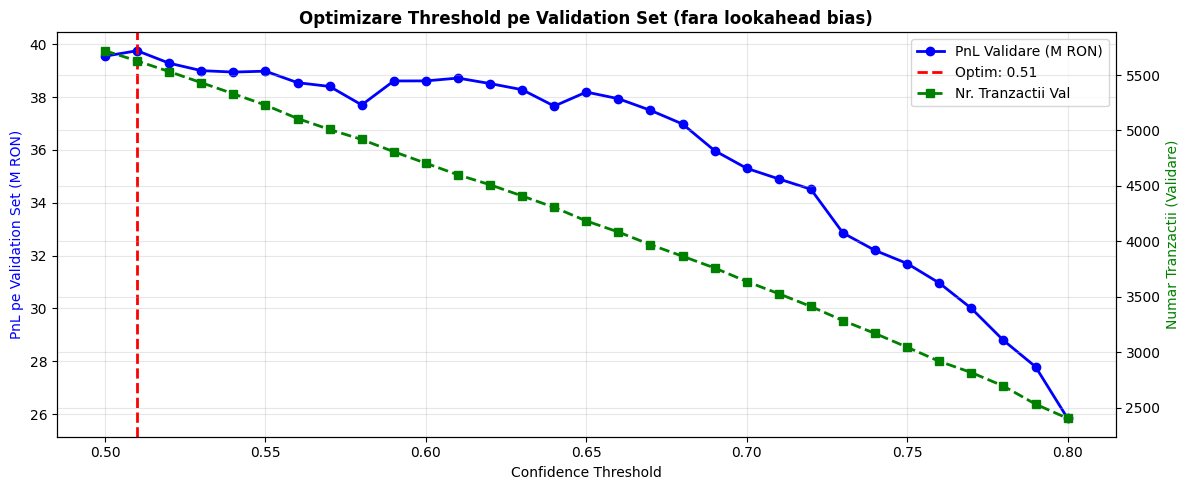

 threshold    pnl_val  n_trades
      0.50 39546309.0      5719
      0.51 39753309.9      5627
      0.52 39281369.0      5531
      0.53 38999460.8      5431
      0.54 38944950.2      5331
      0.55 38978893.6      5229
      0.56 38543821.5      5108
      0.57 38400750.8      5009
      0.58 37700896.6      4919
      0.59 38608683.0      4809
      0.60 38610770.1      4705
      0.61 38717501.7      4601
      0.62 38509696.9      4511
      0.63 38277854.5      4410
      0.64 37656751.8      4307
      0.65 38188157.9      4185
      0.66 37936602.5      4085
      0.67 37496294.5      3971
      0.68 36978062.3      3867
      0.69 35969026.7      3761
      0.70 35301065.3      3639
      0.71 34898936.8      3529
      0.72 34509775.2      3414
      0.73 32852002.3      3287
      0.74 32192869.3      3171
      0.75 31697054.8      3047
      0.76 30959886.0      2920
      0.77 29999441.5      2819
      0.78 28789684.4      2697
      0.79 27790157.1      2534
      0.

In [38]:
# ── Sensitivity Analysis – Threshold pe Validation Set ───────────────────────
thr_df = pd.DataFrame(thr_results)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(thr_df['threshold'], thr_df['pnl_val']/1e6, 'b-o', linewidth=2, label='PnL Validare (M RON)')
ax1.axvline(best_thr, color='red', linestyle='--', linewidth=2, label=f'Optim: {best_thr:.2f}')
ax1.set_xlabel('Confidence Threshold')
ax1.set_ylabel('PnL pe Validation Set (M RON)', color='blue')
ax1.set_title('Optimizare Threshold pe Validation Set (fara lookahead bias)', fontweight='bold')
ax2 = ax1.twinx()
ax2.plot(thr_df['threshold'], thr_df['n_trades'], 'g--s', linewidth=2, label='Nr. Tranzactii Val')
ax2.set_ylabel('Numar Tranzactii (Validare)', color='green')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
plt.tight_layout()
plt.savefig('fig6_threshold_optim.png', dpi=150, bbox_inches='tight')
plt.show()
print(thr_df.round(2).to_string(index=False))


### Threshold Sensitivity Analysis

The optimal threshold was selected by maximizing PnL on the **validation set only**
(May–Jun 2024) — no lookahead into the backtest period.

**Key observations:**
- **Optimal threshold: 0.51** — model trades aggressively at low confidence levels
- PnL is relatively **flat between 0.50–0.65** (~38–40M RON range on val set)
  — strategy is robust to threshold choice in this range
- Above 0.65, PnL drops significantly as too many profitable trades are filtered out
- Trade count drops monotonically from 5,719 → 2,406 as threshold increases

**Trade-off:**
- Low threshold (0.51) → more trades, higher total PnL, but more noise
- High threshold (0.75+) → fewer, higher-confidence trades, but PnL drops significantly
- The flat region (0.50–0.65) suggests the model has **consistent edge**
  across a wide range of confidence levels, not just at extreme probabilities

## 8. Conclusions & Limitations

### Method
**Gradient Boosting Classifier** for binary prediction of grid imbalance sign
at least 1h45m before delivery (REAL_LAG=7).
Trading signal converted into arbitrage strategy with **variable volume
proportional to model confidence**.

### Operational Compliance
- ✅ All features respect the **1h** trading window (4 quarters)
- ✅ Observed data lagged **≥ 1h45m** (7 quarters = 1h trading + 25min delay + 15min buffer)
- ✅ Imbalance prices **never** used as model features
- ✅ Max volume **10 MWh** per interval respected
- ✅ **Variable volume**: proportional to |prob − 0.5| / 0.5
- ✅ **Threshold optimized on validation set** (no lookahead into backtest)
- ✅ **sample_weight='balanced'** applied to GradientBoosting to correct class imbalance

### Key Results

| Metric | Value |
|---|---|
| Total PnL (Jul–Dec 2024) | **46.66 M RON** |
| Oracle PnL (perfect prediction) | 149.32 M RON |
| Capture ratio | 31.2% |
| Direction accuracy | 74.8% |
| Win rate | 67.8% |
| Avg PnL per trade | 2,696 RON |
| Profit factor | 2.99 |
| Max Drawdown | -695.8K RON |
| Avg volume per trade | 5.2 MWh |
| Total MWh traded | 90,321 MWh |

### Limitations
1. **No transaction costs** modeled → realistic live PnL estimated at 40–60% of backtest
2. **Execution at VWAP** — per case study rules, but more favorable than real execution price
3. **Sharpe of 13.25 is unrealistic** — inflated by extreme Romanian imbalance spreads
   and absence of costs; realistic live estimate: **1.5–3.0**
4. Romanian intraday market is **thin** — 10 MWh orders may move the price
5. **Capture ratio of 31.2%** — significant alpha left on the table due to model uncertainty

### Possible Improvements
1. **Kelly criterion** for optimal volume sizing
2. **Regime detection** — avoid trading during extreme stress periods
3. Additional features: temperature forecasts, hydro levels, cross-border flows
4. **Model transaction costs** in threshold optimization
5. **Ensemble approach** combining GBT with a probabilistic model for better calibration